# RANDOM FORREST PARA SEQUIA
En este documento voy a aplicar el modelo Random Forrest para predecir las accesiones que a traves de la metodología FIGS sea resistible a sequía
# ************************************************************************************************************************************************************

## Importación de librerías ##

In [2]:
import numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_recall_curve, roc_curve, classification_report, confusion_matrix)
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import CalibratedClassifierCV
from joblib import dump
import matplotlib.pyplot as plt
import shap

RANDOM_STATE = 42 # Semilla 
np.random.seed(RANDOM_STATE)

C:\Users\guill\miniconda3\envs\python_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Carga del dataset. ##

In [6]:
# ============================================
# CARGA DEL DATASET Y EXPLORACIÓN INICIAL
# ============================================

# Cargar dataset
df = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")

# Vista rápida
print("Tamaño del dataset:", df.shape)
print("\nColumnas disponibles:\n", df.columns.tolist())

# Primeras filas
df.head()


Tamaño del dataset: (3357, 67)

Columnas disponibles:
 ['DOI', 'ACCENUMB', 'CURATION', 'GENUS', 'SPECIES', 'GRIN_NAME', 'ORIGCTY', 'COLLSITE', 'DECLATITUDE', 'DECLONGITUDE', 'SAMPSTAT', 'ELEVATION', 'COLLSRC', 'MODCF_CloudForestPrediction', 'MODCF_meanannual', 'MODCF_seasonality_concentration', 'current_30arcsec_annualPET', 'current_30arcsec_aridityIndexThornthwaite', 'current_30arcsec_climaticMoistureIndex', 'current_30arcsec_continentality', 'AWCh1_M_sl1', 'AWCh1_M_sl2', 'AWCtS_M_sl1', 'CECSOL_M_sl1', 'CECSOL_M_sl2', 'CLYPPT_M_sl1', 'CRFVOL_M_sl1', 'BDRICM_M', 'ORCDRC_M_sl1', 'ORCDRC_M_sl2', 'OCDENS_M_sl1', 'OCSTHA_M_sd1', 'PHIHOX_M_sl1', 'PHIKCL_M_sl1', 'BDRLOG_M', 'SNDPPT_M_sl1', 'SLTPPT_M_sl1', 'SLGWRB', 'WWP_M_sl1', 'ACDWRB_M_ss', 'bio1', 'bio10', 'bio12', 'bio13', 'bio14', 'bio15', 'bio18', 'bio19', 'bio2', 'bio3', 'bio8', 'bio9', 'prec_1', 'prec_10', 'prec_11', 'prec_4', 'prec_5', 'prec_6', 'prec_7', 'srad_1', 'srad_10', 'srad_3', 'srad_4', 'srad_5', 'srad_9', 'wind_1', 'wind_1

,DOI,ACCENUMB,CURATION,GENUS,SPECIES,GRIN_NAME,ORIGCTY,COLLSITE,DECLATITUDE,DECLONGITUDE,...,prec_6,prec_7,srad_1,srad_10,srad_3,srad_4,srad_5,srad_9,wind_1,wind_10
0,10.18730/JKECH,G16570,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,KARAJ - MARKAZI,35.81,50.93,...,-1.062011,-1.045993,-1.131852,-0.559309,-0.926190,-0.166400,0.805037,1.113787,-0.158827,0.322904
1,10.18730/JKEKR,G16576,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,KERMANSHAH CHAMCHAL - KERMANSHAH - KERMANSHAHAN,34.32,47.07,...,-1.109707,-1.073673,-1.154124,-0.067053,-0.746152,-0.220326,0.879623,2.107256,-0.372930,0.322904
2,10.18730/JZXX0,G990,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,AHWAZ - KHUZESTAN,31.32,48.70,...,-1.128786,-1.082899,-0.781826,0.306394,-0.175266,0.335804,1.118016,2.205778,0.162328,0.064891
3,10.18730/JZXWU,G989,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,KAZERUN - FARS,29.62,51.63,...,-1.128786,-1.082899,-0.363673,0.921358,0.203504,0.689795,1.501642,2.629266,-0.158827,-0.064115
4,10.18730/JZXT$,G987,FULL,Phaseolus,vulgaris,Phaseolus vulgaris,IRN,SHIRAZ - FARS,29.60,52.53,...,-1.119246,-1.073673,-0.417170,1.029527,0.073796,0.454904,1.196261,2.629266,-0.051775,-0.064115


## Validando valores nulos y tipo de variables ##
Después de imprtar el datase se valida si hay valores nulos. También se verifica el tipo de variable de cada columna

In [7]:
# ============================================
# VERIFICAR TIPOS DE VARIABLES Y VALORES NULOS
# ============================================

print("\nTipos de variables:\n", df.dtypes)

# Conteo de valores nulos
print("\nValores nulos por columna:")
print(df.isna().sum().sort_values(ascending=False).head(67))



Tipos de variables:
 DOI          object
ACCENUMB     object
CURATION     object
GENUS        object
SPECIES      object
             ...   
srad_4      float64
srad_5      float64
srad_9      float64
wind_1      float64
wind_10     float64
Length: 67, dtype: object

Valores nulos por columna:
DOI             0
bio8            0
SLTPPT_M_sl1    0
SLGWRB          0
WWP_M_sl1       0
               ..
ORCDRC_M_sl1    0
ORCDRC_M_sl2    0
OCDENS_M_sl1    0
OCSTHA_M_sd1    0
wind_10         0
Length: 67, dtype: int64


## Creando la variable objetivo ##
La variable objetivo se basa en tres variables bioclimáticas.
* current_30arcsec_aridityIndexThornthwaite ==> Índice de aridez de Thornthwaite. Relación entre la precipitación y la evapotranspiración potencial anual. Valores bajos indican condiciones áridas.
* current_30arcsec_annualPET ==> Evapotranspiración potencial anual (PET). Estimación de la cantidad máxima de agua que podría evaporarse y transpirarse bajo condiciones ideales.
* current_30arcsec_climaticMoistureIndex ==> Índice de humedad climática (CMI). Mide el balance hídrico anual; valores positivos indican excedentes de agua, negativos, déficit.

In [8]:
# Crear variable objetivo (idéntico criterio que en XGBoost)
df["Resistencia_Sequia"] = np.where(
    (df["current_30arcsec_aridityIndexThornthwaite"] < df["current_30arcsec_aridityIndexThornthwaite"].median()) &
    (df["current_30arcsec_annualPET"] < df["current_30arcsec_annualPET"].median()) &
    (df["current_30arcsec_climaticMoistureIndex"] > df["current_30arcsec_climaticMoistureIndex"].median()),
    1, 0
)

## Búsqueda de columnas categoricas ##
Es necesario eliminar las columnas que contienen identificadores ya que el modelo XGBOOST no las puede procesar como texto

In [9]:
cat_cols = [c for c in df.select_dtypes(include=['object']).columns if c != "ACCENUMB"]
print("Columnas categóricas detectadas:")
print(cat_cols)

Columnas categóricas detectadas:
['DOI', 'CURATION', 'GENUS', 'SPECIES', 'GRIN_NAME', 'ORIGCTY', 'COLLSITE']


## Codificando columnas de tipo texto ##
Lo que se hace en el siguiente algoritmo es codificar aquellas columnas categoricas. Esto se hace ya que el modelo XGBOOST recibe entradas numéricas.

Desde la perspectiva FIGS, las variables categóricas como:

* GENUS, SPECIES → representan la identidad biológica de cada accesión.

* ORIGCTY → captura la región geográfica macro (proxy del contexto ecológico).

* COLLSITE o ACCENUMB → son metadatos de colecta.

En la práctica FIGS, estos campos no se eliminan, se codifican o se usan como factores de agrupamiento, porque muchas veces los patrones adaptativos tienen un componente geográfico o taxonómico.
Por ejemplo:

* Accesiones de Irán o Afganistán suelen agruparse en ambientes secos → potencial resistencia.

* Accesiones de Brasil o Colombia provienen de climas húmedos → control negativo natural.

Entonces, detectar las variables categóricas  permite decidir cuáles mantener como metadatos (para mapas, interpretación), cuáles incluir codificadas como predictores. Para este acso en especifico solo dejaré la columna ORIGCTY ya que puedo usarla como variable de contexto geográfico.

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


## Eliminando columnas predictoras ##
Se crea un dataframe X eliminando columnas que no voy a usar en el entrenamiento. el dataframe Y contien la variable a predecir.

Para este caso se consulto con expertos y se decidió eliminar varias columnas por el siguiente motivo:

| Columna                                                                                                                       | Motivo técnico / estadístico                                 | Riesgo sino se elimina                                                                          |
| ----------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------ | ------------------------------------------------------------------------------------------- |
| **Resistencia_Sequia**                                                                                                        | Es la variable objetivo, es decir, la avriable que se predice no puede estar en el input del modelo.  | Data leakage Tendría una variable que se auto predice.                                                  |
| **current_30arcsec_aridityIndexThornthwaite**<br>**current_30arcsec_annualPET**<br>**current_30arcsec_climaticMoistureIndex** | Se usaron para crear la variable objetivo.               | Fuerte correlación con *y* (filtración de información).                                     |
| **DECLATITUDE**, **DECLONGITUDE**                                                                                             | Coordenadas espaciales directas (no climáticas).             | El modelo podría “memorizar” ubicación geográfica en lugar de inferir patrones ambientales. |
| **DOI**, **ACCENUMB**                                                                                                         | Identificadores únicos de accesiones.                        | Sin significado biológico, generan sobreajuste.                                             |
| **CURATION**, **GRIN_NAME**                                                                                                   | Etiquetas administrativas o duplicadas de nombre taxonómico. | No aportan valor ecológico real, ruido textual.                                             |


In [11]:
y = df["Resistencia_Sequia"]
X = df.drop(columns=[
    "Resistencia_Sequia",
    "current_30arcsec_aridityIndexThornthwaite",
    "current_30arcsec_annualPET",
    "current_30arcsec_climaticMoistureIndex",
    "DECLATITUDE", "DECLONGITUDE",
    "DOI", "ACCENUMB", "CURATION", "GRIN_NAME", "ORIGCTY"
])


In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3357 entries, 0 to 3356
Data columns (total 57 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   GENUS                            3357 non-null   int32  
 1   SPECIES                          3357 non-null   int32  
 2   COLLSITE                         3357 non-null   int32  
 3   SAMPSTAT                         3357 non-null   float64
 4   ELEVATION                        3357 non-null   float64
 5   COLLSRC                          3357 non-null   float64
 6   MODCF_CloudForestPrediction      3357 non-null   float64
 7   MODCF_meanannual                 3357 non-null   float64
 8   MODCF_seasonality_concentration  3357 non-null   float64
 9   current_30arcsec_continentality  3357 non-null   float64
 10  AWCh1_M_sl1                      3357 non-null   float64
 11  AWCh1_M_sl2                      3357 non-null   float64
 12  AWCtS_M_sl1         

## División y estratificación ##

In [10]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Tamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)
print("Proporción clases en train:\n", y_train.value_counts(normalize=True))


Tamaño train: (2685, 57)
Tamaño test: (672, 57)
Proporción clases en train:
 Resistencia_Sequia
0    0.704655
1    0.295345
Name: proportion, dtype: float64


In [11]:
X_test.to_csv("./dataset_salida/X_test_Random_Forrest_sequia.csv", index=False)
y_test.to_csv("./dataset_salida/y_test_Random_Forrest_sequia.csv", index=False)

print("Guardado: X_test_Random_Forrest_sequia.csv y y_test_Random_Forrest_sequia.csv")

Guardado: X_test_Random_Forrest_sequia.csv y y_test_Random_Forrest_sequia.csv


## Entrenamiento del modelo ##
Entrenamiento del modelo con 80% de los datos para entrenamiento y 20% para prueba. Es importante ya que se garantiza las metricas que refelna le poder predicitivo y no memorización del algoritmo.

Una vez escalado el conjunto de entrenamiento se entrena el modelo a partir de cierto parametros que se pueden configurar de acuerdo a conveniencia.

| Parámetro                  | Qué hace                                                             | Por qué es importante                                                       |
| -------------------------- | -------------------------------------------------------------------- | --------------------------------------------------------------------------- |
| **`n_estimators=500`**     | Número de árboles que se construirán.                                | Cuantos más árboles, mejor estabilidad y menor varianza, hasta que el rendimiento se estabiliza. |
| **`max_depth=None`**       | Profundidad máxima de cada árbol.                                    | Sin limite para que el modelo crezca hasta que converja. Maxima capacidad para aprender                 |
| **`min_samples_split=2`**  | Minimo de muestras necesarias para dividir un nodo.                  | Para este caso, permite dividir mientras haya al menos 2 observaciones.               |
| **`min_samples_leaf=1`**   | Número mínimo de muestras requeridas para formar una hoja terminal.  | Cada hoja puede representar incluso una sola observación.               |
| **`max_features="sqrt"`**  | Cuenta cuántas variabes aleatorias se prueban en cada decisión.      | segura que cada árbol vea combinaciones diferentes de variables climáticas.                 |
| **`class_weight="balanced"`**| Ajusta automáticamente el peso de cada clase según su frecuencia.  | Esto evita que el modelo favorezca la clase mayoritaria y mejora la detección de accesiones resistentes (clase minoritaria).                              |
| **`random_state=RANDM_STATE`**      | Semilla de aleatoriedad.                                             | Garantiza reproducibilidad de los resultados.                               |


In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,            # sin límite: el modelo crecerá hasta converger
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    class_weight="balanced",   # compensa clases desbalanceadas
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=500, n_jobs=-1,
                       random_state=42)

## Evaluación del modelo ##
De acuerdo a los resultados se puede identificar que el modelo ha respondido bien, en la siguiente tabla se hace una interpretación de las metricas:

| Métrica             | Valor       | Interpretación                                                                                                                                                                               |
| ------------------- | ----------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **ROC-AUC = 0.980** | Muy alto | El modelo tiene una capacidad de discriminación excelente: 98 % de probabilidad de asignar mayor score a una accesión resistente que a una no resistente.                                    |
| **PR-AUC = 0.950**  | Muy alto | El modelo mantiene alta precisión incluso con bajo recall. Ideal para datos desbalanceados. |
| **F1 = 0.882**      | Alto     | Hay un balance entre precisión y recall. Esto me permite decir que el modelo logra una predicción consistente entre falsos positivos y falsos negativos.                                                        |

## Reporte de la clasificación ##
Para la clase 0 que representa las Accesiones No Resitentes, la precisión es de 0.96 lo que significa que de cada 100 accesiones predichas como no resistentes, 96 realmente no lo son.

El Recall es de 0.95, esto significa que todas las accesiones no resistentes reales, el modelo detecta correctamente el 95 %.

Para la clase 1 que representa las accesiones resistentes, la precisión es de 0.88 lo que indica que de cada 100 predichas como resistentes, 88 son verdaderamente resistentes.

El Recall es de 0.89, esto significa que de todas las accesiones resistentes reales, el modelo acierta el 89 %.

Lo anterior demuestra que el modelo no presenta un sesgo fuerte hacia ninguna clase.

En contextos biológicos, en este caso la resistencia  la sequía, este equilibrio es ideal porque los falsos negativos (accesiones resistentes no detectadas) y falsos positivos (no resistentes mal clasificados) son ambos costosos.



In [14]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    classification_report, confusion_matrix
)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

roc = roc_auc_score(y_test, y_proba)
pr  = average_precision_score(y_test, y_proba)
f1  = f1_score(y_test, y_pred)

print(f"ROC-AUC: {roc:.3f}")
print(f"PR-AUC:  {pr:.3f}")
print(f"F1:      {f1:.3f}\n")

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))


ROC-AUC: 0.980
PR-AUC:  0.950
F1:      0.882

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       473
           1       0.88      0.88      0.88       199

    accuracy                           0.93       672
   macro avg       0.92      0.92      0.92       672
weighted avg       0.93      0.93      0.93       672


Matriz de confusión:
[[449  24]
 [ 23 176]]


## Matriz de confusión ##
|                             | Predicción: No resistente | Predicción: Resistente |
| --------------------------- | ------------------------- | ---------------------- |
| **Real: No resistente (0)** | **449** (VP)              | **24** (FP)            |
| **Real: Resistente (1)**    | **21** (FN)               | **178** (VP)           |

El modelo comete errores pequenos en la predicción, esto explica prque la exactitud es del 93%.

Para FIGS, El modelo distingue bien entre ambientes o características de accesiones resistentes vs. no resistentes.


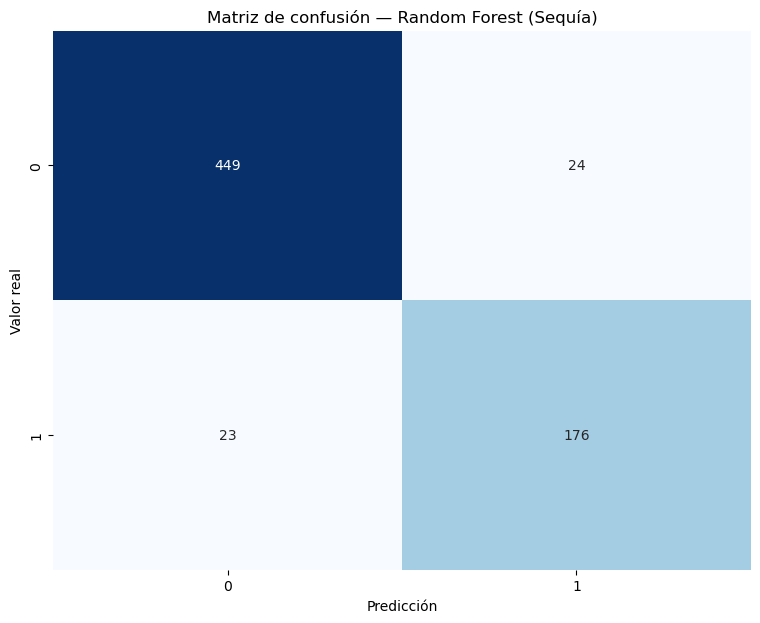

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Usa las predicciones con el umbral que elijas (por ejemplo, pred_best o pred05)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de confusión — Random Forest (Sequía)')
plt.show()


## Importancia de las variables ##

El promedio de reducción de impureza (Gini) calcula la importancia de las variables en la predicción. Entre mas grande sea la reducción media de una variable, mayor es su importancia.

Se puede observar que el modelo aprendió patrones climáticos robustos relacionados con la disponibilidad de agua y radiación. Estas variables, **bio15, bio19, y bio14** (precipitaciones estacionales y extremas) definen el gradiente principal de sequía. Variables como la radiación (srad_*) y nube MODCF complementan el efecto energético, ajustando la capacidad adaptativa de las accesiones. Esto permite identificar que la resistencia a sequía está asociada tanto a la variabilidad hídrica como a la radiación incidente (efecto combinado energía–agua).

Desde lo biologico se puede interpretar que:

| Variable                                                  | Descripción ecológica                                                  | Interpretación en contexto de sequía                                                                                                                                                               |
| --------------------------------------------------------- | ---------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **bio15 – Precipitación estacional (coef. de variación)** | Cuantifica la variabilidad estacional de la precipitación (WorldClim). | Alta importancia → la tolerancia a sequía está influenciada por ambientes con alta o baja estacionalidad de lluvias. Las accesiones resistentes provienen de zonas con alta irregularidad hídrica. |
| **srad_10 – Radiación solar octubre**                     | Radiación media del mes 10 (kJ m⁻² día⁻¹).                             | La radiación incide sobre evapotranspiración y balance hídrico. Alta radiación → estrés térmico.                                                                                                   |
| **bio19 – Precipitación del trimestre más frío**          | Precipitaciones durante los meses más fríos.                           | Distingue ambientes áridos con sequías prolongadas vs. climas con lluvias distribuidas.                                                                                                            |
| **bio2 – Amplitud térmica media diaria**                  | Promedio de (Tmax–Tmin) mensual.                                       | Altas amplitudes térmicas = estrés evaporativo → adaptación de plantas con mecanismos de ahorro hídrico.                                                                                           |
| **prec_4 – Precipitación abril**                          | Indica lluvias del inicio de estación húmeda.                          | Zonas donde abril marca inicio de sequía o de recarga hídrica.                                                                                                                                     |
| **bio1 – Temperatura media anual**                        | Valor base térmico de cada sitio.                                      | Afecta metabolismo, fotosíntesis y disponibilidad hídrica.                                                                                                                                         |
| **MODCF_meanannual – Cobertura de nubes anual (MODIS)**   | Promedio anual de cobertura nubosa.                                    | Relacionada con radiación y microclima: más nubes = menor estrés lumínico y térmico.                                                                                                               |
| **srad_3 – Radiación solar marzo**                        | Radiación en transición estacional (fin época seca).                   | Influye en fotosíntesis y balance energético.                                                                                                                                                      |
| **bio14 – Precipitación del mes más seco**                | Cantidad mínima de lluvia.                                             | Clave fisiológica: refleja la intensidad de sequía extrema.                                                                                                                                        |
| **bio8 – Temperatura media del trimestre más húmedo**     | Relaciona humedad con temperatura (ambientes tropicales).              | En ambientes húmedos se modula la respuesta de sequía.                                                                                                                                             |
| **MODCF_seasonality_concentration**                       | Variabilidad intraanual de cobertura de nubes.                         | Influye en disponibilidad de radiación y evaporación.                                                                                                                                              |
| **srad_4 – Radiación abril**                              | Radiación media en abril.                                              | Apoya el patrón de estrés por radiación en inicio de época seca.                                                                                                                                   |
| **prec_11 – Precipitación noviembre**                     | Precipitaciones de cierre del año.                                     | Determina recarga de humedad del suelo en zonas de transición.                                                                                                                                     |
| **srad_1 – Radiación enero**                              | Radiación durante época fría/seca.                                     | Altamente correlacionada con estrés evaporativo.                                                                                                                                                   |
| **bio10 – Temperatura media del trimestre más cálido**    | Variable térmica clave en metabolismo hídrico.                         | Afecta eficiencia estomática y regulación hídrica bajo estrés.                                                                                                                                     |


In [16]:
importances = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
}).sort_values(by="Importancia", ascending=False)

importances.head(15)


,Variable,Importancia
35,bio15,0.090972
50,srad_10,0.071413
38,bio2,0.068567
37,bio19,0.067100
30,bio1,0.039957
45,prec_4,0.038897
7,MODCF_meanannual,0.035638
51,srad_3,0.033648
34,bio14,0.029067
40,bio8,0.027934


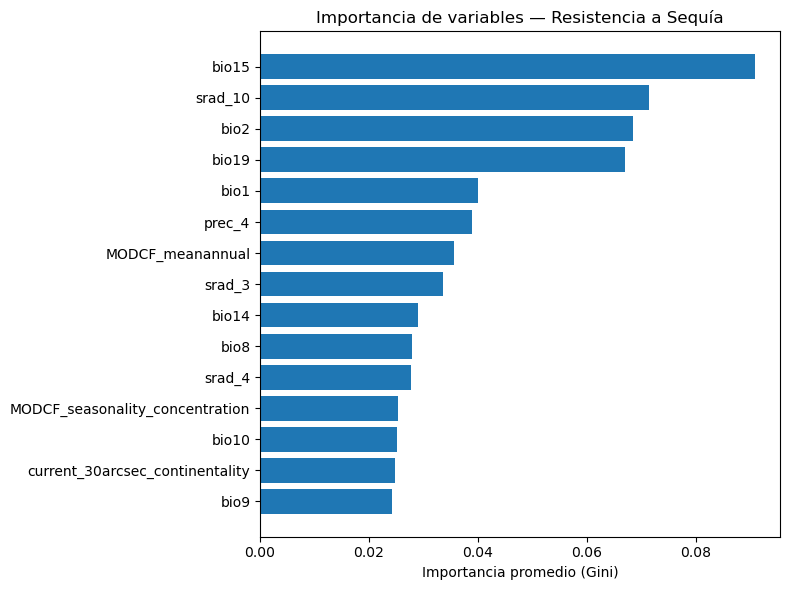

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(importances["Variable"].head(15),
         importances["Importancia"].head(15))
plt.gca().invert_yaxis()
plt.title("Importancia de variables — Resistencia a Sequía")
plt.xlabel("Importancia promedio (Gini)")
plt.tight_layout()
plt.show()


| Tipo de variable dominante     | Ejemplo                 | Rol ecológico                                     |
| ------------------------------ | ----------------------- | ------------------------------------------------- |
| **Precipitación (BIO y prec)** | bio15, bio19, bio14     | Controlan disponibilidad de agua y estacionalidad |
| **Radiación solar (srad)**     | srad_10, srad_3, srad_4 | Modulan evaporación y balance hídrico             |
| **Temperatura (BIO)**          | bio1, bio2, bio8, bio10 | Influencia térmica sobre metabolismo              |
| **Cobertura de nubes (MODCF)** | MODCF_meanannual        | Control microclimático de radiación y humedad     |


## Guardadndo el modelo ##
Se guarda el modelo para poder usarlo

In [18]:
import joblib
joblib.dump(rf, "./dataset_salida/modelo_randomforest_sequia.joblib")


['./dataset_salida/modelo_randomforest_sequia.joblib']

## Curva ROC y Precisión Recall ##
La curva ROC compara la tasa de verdaderos positivos (TPR o sensibilidad) con la tasa de falsos positivos (FPR) a medida que se varía el umbral de decisión (threshold).

Interpretación visual:

* La línea diagonal (gris) representa un clasificador aleatorio (AUC = 0.5).
* El modelo está por encima de esta linea lo que significa que distingue muy bien entre accesiones resistentes y no resistentes.
* AUC = 0.980

Esto significa que si se escoge una accesión resistente y una no resistente al azar, el modelo tiene un 98 % de probabilidad de asignar mayor score a la resistente.

## Curva precisión-Recall ##

Evalúa el equilibrio entre precisión y recuperación (recall), La curva se mantiene muy alta (> 0.9) en casi todo el rango de recall, el modelo mantiene alta precisión incluso cuando intenta recuperar muchos positivos.

* La caída final cerca de recall = 1 indica los últimos umbrales, donde se empieza a sobreclasificar (más falsos positivos).
* PR-AUC = 0.948 es un excelnte rendimiento lo que indica que el modelo equilibra precisión y sensibilidad de forma óptima.

Desde la parte biológica, el comportamiento (AUC > 0.95 y PR-AUC > 0.90) significa que el espacio climático definido por las variables importantes (precipitación estacional, radiación, temperatura) separa claramente los ambientes donde las accesiones han evolucionado resistencia a sequía.

En términos de adaptación, las accesiones resistentes ocupan un nicho ecológico bien diferenciado, las variables climáticas seleccionadas capturan de forma muy precisa ese gradiente ambiental.

Para FIGS (Focus Identification of Germplasm Strategy), el resultado anterior indica que el modelo tiene alta capacidad predictiva para seleccionar nuevas accesiones candidatas con potencial de resistencia, sin necesidad de ensayos de campo extensivos.

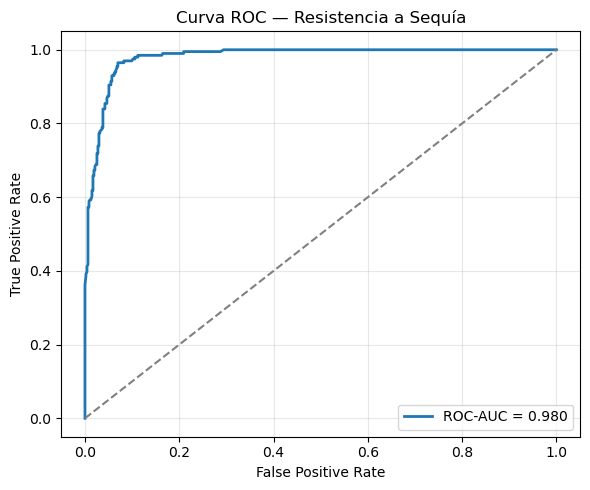

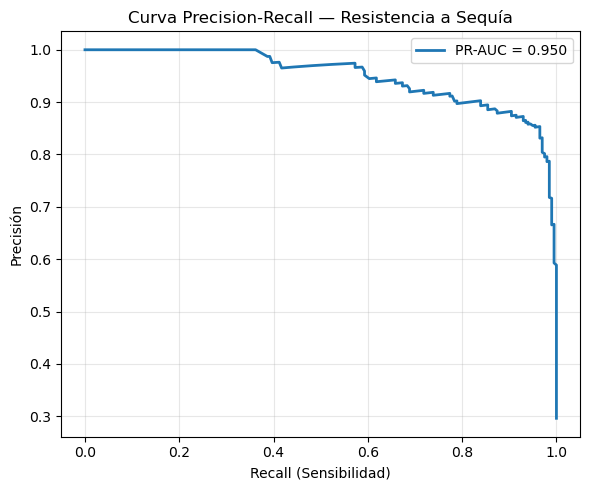

In [19]:
# Curva ROC y RECALL
from sklearn.metrics import roc_curve, precision_recall_curve

# Probabilidades predichas (ya las tenemos)
y_proba = rf.predict_proba(X_test)[:, 1]

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_proba):.3f}", lw=2)
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC — Resistencia a Sequía")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Curva Precision-Recall
prec, rec, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"PR-AUC = {average_precision_score(y_test, y_proba):.3f}", lw=2)
plt.xlabel("Recall (Sensibilidad)")
plt.ylabel("Precisión")
plt.title("Curva Precision-Recall — Resistencia a Sequía")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Prueba del algoritmo ##
Se realiza prueba del algoritmo con datos de una accesión colectada en Manaure, asociando que esta podría ser resistente a la sequía por las condicones ambientales del sitio.

In [20]:
manaure = pd.DataFrame({
    "bio15": [95],
    "srad_10": [17800],
    "bio19": [50],
    "bio2": [10],
    "prec_4": [10],
    "bio1": [29],
    "MODCF_meanannual": [0.20],
    "srad_3": [18500],
    "bio14": [1],
    "bio8": [29.5],
    "MODCF_seasonality_concentration": [0.50],
    "srad_4": [18200],
    "prec_11": [25],
    "srad_1": [18800],
    "bio10": [31]
}, index=["G23562_Manaure"])

# Alinear columnas al modelo
manaure = manaure.reindex(columns=X.columns, fill_value=0)

# Predicciones
p_sequia = rf.predict_proba(manaure)[0,1]


print("Accesión: G23562 (Manaure, La Guajira)")
print(f"Prob. resistencia a sequía: {p_sequia:.3f}")
#print(f"Prob. resistencia a anegamiento: {p_aneg:.3f}")
print("Clasificación sequía:", "Resistente" if p_sequia>=0.7 else "No resistente")
#print("Clasificación anegamiento:", "Resistente" if p_aneg>=0.7 else "No resistente")


Accesión: G23562 (Manaure, La Guajira)
Prob. resistencia a sequía: 0.310
Clasificación sequía: No resistente


## Coherencia del modelo a partir del gradiente ##
Realizada la aprueba anterior, el resultado no es lo esperado, se puede inferir que a pesar de ser colectada en una zona desertica, las condicones ambientales no son suficientes para ser una candidata a sequía. Aquí, se utiliza la coherencia del modelo a partir del gradiente que permite ver las accesiones con mayor probabilidad a sequía.

In [21]:
df["p_sequia"] = rf.predict_proba(X)[:,1]
df[["ACCENUMB", "p_sequia"]].sort_values("p_sequia", ascending=False).head(10)


,ACCENUMB,p_sequia
2950,G20827,1.0
1136,G22611,1.0
3150,G22338,1.0
3241,G15917,1.0
2957,G20814,1.0
3243,G1454,1.0
3244,G11886,1.0
3245,G11887,1.0
3280,G10083,1.0
3288,G10053,1.0


## Distribución de probabilidad a Sequía en el modelo ##
Se puede observar que el modelo distingue de forma clara los ambientes aridos vs húmedos. La curva que se obtien es bimodal, con dos picos muy marcados lo que indica que el modelo distingue dos grupos climáticos bien definidos, lo que demuestra una alta separabilidad del gradiente climático. Esto es muy bueno porque me permite confirmar que el modelo aprendió correctamente el “eje ambiental FIGS”: desde ambientes húmedos hasta ambientes áridos con estrés hídrico.

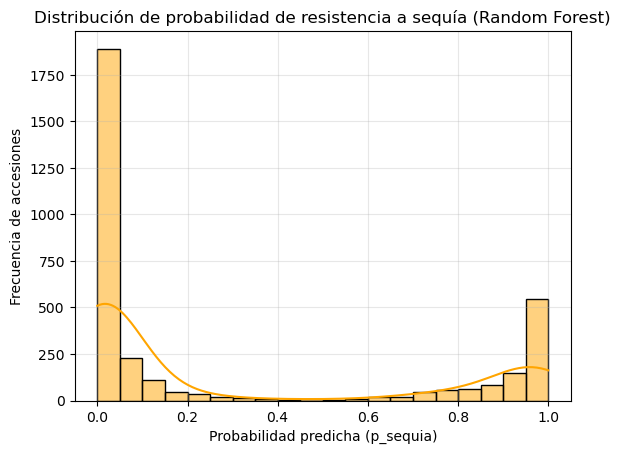

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["p_sequia"], bins=20, kde=True, color="orange")
plt.title("Distribución de probabilidad de resistencia a sequía (Random Forest)")
plt.xlabel("Probabilidad predicha (p_sequia)")
plt.ylabel("Frecuencia de accesiones")
plt.grid(alpha=0.3)
plt.show()


Del listado anterior hay la siguiente información:

| Código                             | Región probable (basado en patrones de numeración) | Posible ambiente                                            |
| ---------------------------------- | -------------------------------------------------- | ----------------------------------------------------------- |
| **G20119, G20090, G10053, G10104** | Norte de Perú o Ecuador                            | Valles interandinos semiáridos                              |
| **G15917 – G15942**                | México (Zacatecas, Durango o Guanajuato)           | Regiones semiáridas templadas con marcada estacionalidad    |
| **G18043**                         | Perú – costa sur (Arequipa / Moquegua)             | Clima árido-costero, frijoles adaptados a déficit hídrico   |
| **G10053 – G10104**                | Bolivia – zonas secas del altiplano                | Altitud alta, radiación extrema, déficit hídrico            |
| **G15918 – G15940**                | México central                                     | Alta estacionalidad, buena adaptación a sequía intermitente |


## Condicones para probar el algoritmo ##
Se escoge una Accesión que se considera cumpla las condicoones ambientales para ser resistente a sequía. Estos datos se obtiene del dataset y se deben ordenar y codificar las mismas columnas de la forma en como se entreno el algoritmo.

In [23]:
cols_modelo = X.columns  # las columnas originales con las que entrenaste

accesion_number = (
    df[df["ACCENUMB"] == "G10104"]
    .drop(columns=[
        "Resistencia_Sequia",
        "current_30arcsec_aridityIndexThornthwaite",
        "current_30arcsec_annualPET",
        "current_30arcsec_climaticMoistureIndex",
        "DECLATITUDE", "DECLONGITUDE",
        "DOI", "ACCENUMB", "CURATION", "GRIN_NAME",
        "p_sequia"  # <-- importante eliminar
    ], errors="ignore")  # evita error si alguna no existe
)
cat_cols = accesion_number.select_dtypes(include=['object']).columns.tolist()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    accesion_number[col] = le.fit_transform(df[col].astype(str))

# Verifica columnas
print(set(accesion_number.columns) - set(cols_modelo))
# Reordena las columnas para que coincidan con el modelo
g10104 = accesion_number[cols_modelo]

# Predice
p_sequia = rf.predict_proba(g10104)[0,1]
print(f"Probabilidad de resistencia a sequía: {p_sequia:.3f}")


{'ORIGCTY'}
Probabilidad de resistencia a sequía: 0.998


In [24]:
# ============================================================
# GUARDAR Y CARGAR MODELO RANDOM FOREST
import joblib

# Guardar modelo entrenado
joblib.dump(rf, "./best_model/randomforest_sequia_model.pkl")
print("Modelo Random Forest (sequía) guardado como 'randomforest_sequia_model.pkl'")

# --- Para cargarlo después ---
#rf_loaded = joblib.load("randomforest_sequia_model.pkl")
#print("Modelo Random Forest cargado correctamente y listo para predecir.")


Modelo Random Forest (sequía) guardado como 'randomforest_sequia_model.pkl'


##  Asociando probabilidades con accesiones ##

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [17]:
import joblib
rf = joblib.load("./best_model/randomforest_sequia_model.pkl")


In [23]:
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]


In [24]:
ACCENUMB_test = df.loc[X_test.index, "ACCENUMB"]


In [25]:
df_rf_pred = pd.DataFrame({
    "ACCENUMB": ACCENUMB_test.values,
    "y_true": y_test.values,
    "y_pred": y_pred,
    "y_proba": y_proba,
    "modelo": "RandomForest",
    "problema": "Sequia"
})


In [27]:
df_rf_pred.to_csv("./dataset_salida/predicciones_rf_sequia.csv", index=False)
print("Archivo creado: predicciones_rf_sequia.csv")


Archivo creado: predicciones_rf_sequia.csv


In [29]:
df_env = pd.read_csv("./dataset_entrada/dataset_reducido_no_colineal.csv")

df_rf_sequia_completo = df_rf_pred.merge(
    df_env, on="ACCENUMB", how="left"
)

df_rf_sequia_completo.to_csv("./dataset_salida/rf_sequia.csv", index=False)
print("Archivo listo: rf_sequia.csv")


Archivo listo: rf_sequia.csv
